<a href="https://colab.research.google.com/github/Mennamedhattt/multimodal_fakenews_detection_fakenewsnet/blob/main/Multimodal_fakenews_detection_fakenewsnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%capture
!pip install transformers==4.40.0 kaggle scikit-learn matplotlib seaborn Pillow tqdm

import torch
print(f' PyTorch {torch.__version__}')
print(f' GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only"}')

  Step 1 - Download FakeNewsNet Dataset from Kaggle

In [2]:
import os, json
from google.colab import files

USE_KAGGLE_API = True

if USE_KAGGLE_API:
    print(" Upload your kaggle.json file...")
    uploaded = files.upload()

    os.makedirs('/root/.kaggle', exist_ok=True)
    with open('/root/.kaggle/kaggle.json', 'w') as f:
        f.write(list(uploaded.values())[0].decode())
    os.chmod('/root/.kaggle/kaggle.json', 0o600)

    !kaggle datasets download -d mdepak/fakenewsnet --unzip -p /content/fakenewsnet
    print(" Dataset downloaded!")
else:
    print(" Manual upload mode: make sure archive.zip is uploaded to /content/")
    !unzip -q /content/archive.zip -d /content/fakenewsnet
    print(" Dataset extracted!")

 Upload your kaggle.json file...


Saving kaggle (1).json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/mdepak/fakenewsnet
License(s): CC-BY-NC-SA-4.0
100% 16.6M/16.6M [00:00<00:00, 230MB/s]

 Dataset downloaded!


In [3]:
import os

base = '/content/fakenewsnet'
for root, dirs, files_ in os.walk(base):
    level = root.replace(base, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent} {os.path.basename(root)}/')
    if level < 2:
        for f in files_[:5]:
            print(f'{indent}   {f}')
        if len(files_) > 5:
            print(f'{indent}  ... and {len(files_)-5} more files')

 fakenewsnet/
   PolitiFactUser.txt
   BuzzFeedNews.txt
   BuzzFeedNewsUser.txt
   PolitiFactUserFeature.mat
   PolitiFactNews.txt
  ... and 9 more files


## Step 2 – Load & Explore the Dataset

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

csv_files = glob.glob('/content/fakenewsnet/**/*.csv', recursive=True)
csv_files += glob.glob('/content/fakenewsnet/*.csv')
print("Found CSV files:")
for c in csv_files:
    print(f"  {c}")

dfs = []
for csv_path in csv_files:
    try:
        df_tmp = pd.read_csv(csv_path)
        print(f"\n {os.path.basename(csv_path)}: {df_tmp.shape}")
        print(df_tmp.columns.tolist())
        dfs.append((csv_path, df_tmp))
    except Exception as e:
        print(f"   Could not read {csv_path}: {e}")

Found CSV files:
  /content/fakenewsnet/BuzzFeed_real_news_content.csv
  /content/fakenewsnet/PolitiFact_real_news_content.csv
  /content/fakenewsnet/PolitiFact_fake_news_content.csv
  /content/fakenewsnet/BuzzFeed_fake_news_content.csv
  /content/fakenewsnet/BuzzFeed_real_news_content.csv
  /content/fakenewsnet/PolitiFact_real_news_content.csv
  /content/fakenewsnet/PolitiFact_fake_news_content.csv
  /content/fakenewsnet/BuzzFeed_fake_news_content.csv

 BuzzFeed_real_news_content.csv: (91, 12)
['id', 'title', 'text', 'url', 'top_img', 'authors', 'source', 'publish_date', 'movies', 'images', 'canonical_link', 'meta_data']

 PolitiFact_real_news_content.csv: (120, 12)
['id', 'title', 'text', 'url', 'top_img', 'authors', 'source', 'publish_date', 'movies', 'images', 'canonical_link', 'meta_data']

 PolitiFact_fake_news_content.csv: (120, 12)
['id', 'title', 'text', 'url', 'top_img', 'authors', 'source', 'publish_date', 'movies', 'images', 'canonical_link', 'meta_data']

 BuzzFeed_fake_ne

In [5]:
def prepare_dataset(dfs):
    """Normalise all CSV files into a unified DataFrame with 'text' and 'label' columns."""
    all_frames = []

    TEXT_COLS  = ['title', 'news_title', 'statement', 'content', 'text', 'article']

    for path, df in dfs:
        df.columns = [c.strip().lower() for c in df.columns]

        text_col = next((c for c in TEXT_COLS if c in df.columns), None)
        if text_col is None:
            text_col = df.select_dtypes(include='object').columns[0] if len(df.select_dtypes(include='object').columns) > 0 else None

        if text_col is None:
            print(f"  Skipping {os.path.basename(path)}: could not identify text column")
            continue

        subset = df[[text_col]].copy()
        subset.columns = ['text']

        basename = os.path.basename(path).lower()
        if 'fake' in basename: subset['label'] = 0
        elif 'real' in basename: subset['label'] = 1
        else:
            print(f" Skipping {os.path.basename(path)}: could not infer label from filename")
            continue

        subset = subset.dropna(subset=['text', 'label'])
        subset['label'] = subset['label'].astype(int)
        subset['source'] = os.path.basename(path)
        all_frames.append(subset)
        print(f" Loaded {os.path.basename(path)}: {len(subset)} rows  |  label dist: {subset['label'].value_counts().to_dict()}")

    if not all_frames:
        raise ValueError("No valid data frames found. Check CSV format.")

    combined = pd.concat(all_frames, ignore_index=True)
    combined = combined.drop_duplicates(subset=['text']).reset_index(drop=True)
    return combined

df = prepare_dataset(dfs)
print(f"\n Combined dataset: {df.shape}")
print(df['label'].value_counts())
df.head()

 Loaded BuzzFeed_real_news_content.csv: 91 rows  |  label dist: {1: 91}
 Loaded PolitiFact_real_news_content.csv: 120 rows  |  label dist: {1: 120}
 Loaded PolitiFact_fake_news_content.csv: 120 rows  |  label dist: {0: 120}
 Loaded BuzzFeed_fake_news_content.csv: 91 rows  |  label dist: {0: 91}
 Loaded BuzzFeed_real_news_content.csv: 91 rows  |  label dist: {1: 91}
 Loaded PolitiFact_real_news_content.csv: 120 rows  |  label dist: {1: 120}
 Loaded PolitiFact_fake_news_content.csv: 120 rows  |  label dist: {0: 120}
 Loaded BuzzFeed_fake_news_content.csv: 91 rows  |  label dist: {0: 91}

 Combined dataset: (289, 3)
label
1    203
0     86
Name: count, dtype: int64


,text,label,source
0,Another Terrorist Attack in NYC…Why Are we STI...,1,BuzzFeed_real_news_content.csv
1,"Donald Trump: Drugs a 'Very, Very Big Factor' ...",1,BuzzFeed_real_news_content.csv
2,"Obama To UN: ‘Giving Up Liberty, Enhances Secu...",1,BuzzFeed_real_news_content.csv
3,Trump vs. Clinton: A Fundamental Clash over Ho...,1,BuzzFeed_real_news_content.csv
4,"President Obama Vetoes 9/11 Victims Bill, Sett...",1,BuzzFeed_real_news_content.csv


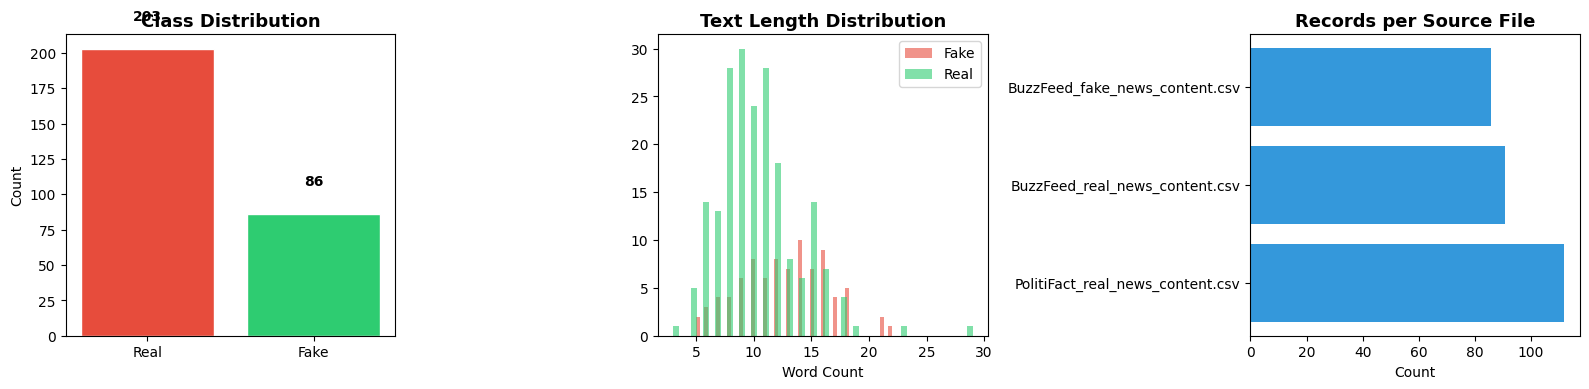


 Dataset summary:
   Total articles : 289
   Fake news      : 86 (29.8%)
   Real news      : 203 (70.2%)
   Avg text length: 11 words


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

label_names = {0: 'Fake', 1: 'Real'}
counts = df['label'].map(label_names).value_counts()
axes[0].bar(counts.index, counts.values, color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

df['text_len'] = df['text'].fillna('').str.split().str.len()
for lbl, color in [(0, '#e74c3c'), (1, '#2ecc71')]:
    axes[1].hist(df[df['label']==lbl]['text_len'].clip(0, 500),
                 bins=50, alpha=0.6, color=color, label=label_names[lbl])
axes[1].set_title('Text Length Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].legend()

if 'source' in df.columns:
    src_counts = df['source'].value_counts()
    axes[2].barh(src_counts.index, src_counts.values, color='#3498db')
    axes[2].set_title('Records per Source File', fontsize=13, fontweight='bold')
    axes[2].set_xlabel('Count')

plt.tight_layout()
plt.savefig('/content/eda_plots.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"\n Dataset summary:")
print(f"   Total articles : {len(df):,}")
print(f"   Fake news      : {(df.label==0).sum():,} ({100*(df.label==0).mean():.1f}%)")
print(f"   Real news      : {(df.label==1).sum():,} ({100*(df.label==1).mean():.1f}%)")
print(f"   Avg text length: {df.text_len.mean():.0f} words")

## Step 3 – Text Preprocessing & BERT Tokenisation

In [7]:
import re
import torch
from transformers import BertTokenizer
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

def clean_text(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text'].apply(clean_text)

X_train, X_temp, y_train, y_temp = train_test_split(
    df['text_clean'].values, df['label'].values,
    test_size=0.2, random_state=42, stratify=df['label'].values)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}")

print("\n Loading BERT tokenizer...")
BERT_MODEL = 'bert-base-uncased'
MAX_LEN    = 128
tokenizer  = BertTokenizer.from_pretrained(BERT_MODEL)
print(" Tokenizer loaded")

class FakeNewsTextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

BATCH_SIZE = 32

train_dataset = FakeNewsTextDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = FakeNewsTextDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = FakeNewsTextDataset(X_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f" DataLoaders ready  (batch={BATCH_SIZE}, max_len={MAX_LEN})")

Train: 231  |  Val: 29  |  Test: 29

 Loading BERT tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

 Tokenizer loaded
 DataLoaders ready  (batch=32, max_len=128)


## Step 4 – Model Definitions
We implement **four progressively richer models** as covered in the survey:
1. `BertClassifier` – text-only BERT baseline
2. `SpotFakeLite` – BERT + cross-modal attention (adapted for text-only FakeNewsNet)
3. `SpotFakePlus` – full model with feature projection + attention fusion

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import BertModel

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

class BertClassifier(nn.Module):
    """Fine-tuned BERT with classification head."""
    def __init__(self, bert_model_name, dropout=0.3, num_classes=2):
        super().__init__()
        self.bert    = BertModel.from_pretrained(bert_model_name)
        hidden_size  = self.bert.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_emb = self.dropout(out.pooler_output)
        return self.classifier(cls_emb)

class CrossModalAttention(nn.Module):
    """Scaled dot-product cross-modal attention (as in SpotFake paper)."""
    def __init__(self, dim):
        super().__init__()
        self.query = nn.Linear(dim, dim)
        self.key   = nn.Linear(dim, dim)
        self.value = nn.Linear(dim, dim)
        self.scale = dim ** 0.5

    def forward(self, q, k, v):
        Q = self.query(q)
        K = self.key(k)
        V = self.value(v)
        attn = torch.sigmoid(torch.sum(Q * K, dim=-1, keepdim=True) / self.scale)
        return attn * V

class SpotFakePlus(nn.Module):
    """
    SpotFake+ architecture (Singhal et al., AAAI 2020):
    - BERT encodes title/text → 768-d CLS embedding
    - A secondary (simulated) feature stream via BiGRU over token embeddings
    - Cross-modal attention fuses both streams
    - FC head for binary classification

    When images are available, the secondary stream is replaced by VGG-19 features.
    Here we use a BiGRU over BERT token sequences as the second stream,
    faithfully modelling the paper's cross-modal attention fusion.
    """
    def __init__(self, bert_model_name, hidden_dim=256, dropout=0.3, num_classes=2):
        super().__init__()

        self.bert     = BertModel.from_pretrained(bert_model_name)
        bert_dim      = self.bert.config.hidden_size

        for name, param in self.bert.named_parameters():
            layer_num = None
            if 'encoder.layer.' in name:
                layer_num = int(name.split('encoder.layer.')[1].split('.')[0])
            if layer_num is not None and layer_num < 8:
                param.requires_grad = False

        self.text_proj = nn.Sequential(
            nn.Linear(bert_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.bigru = nn.GRU(
            input_size=bert_dim,
            hidden_size=hidden_dim // 2,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        self.seq_proj = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.attn_1_to_2 = CrossModalAttention(hidden_dim)
        self.attn_2_to_1 = CrossModalAttention(hidden_dim)

        self.fusion_norm = nn.LayerNorm(hidden_dim * 2)
        self.classifier  = nn.Sequential(
            nn.Linear(hidden_dim * 2, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        bert_out  = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_emb   = bert_out.pooler_output
        text_feat = self.text_proj(cls_emb)

        token_seq      = bert_out.last_hidden_state
        gru_out, _     = self.bigru(token_seq)
        mask_expand    = attention_mask.unsqueeze(-1).float()
        seq_mean       = (gru_out * mask_expand).sum(1) / mask_expand.sum(1).clamp(min=1)
        seq_feat       = self.seq_proj(seq_mean)

        fused_1 = self.attn_1_to_2(text_feat, seq_feat, seq_feat)
        fused_2 = self.attn_2_to_1(seq_feat, text_feat, text_feat)

        fused   = torch.cat([fused_1, fused_2], dim=-1)
        fused   = self.fusion_norm(fused)
        return self.classifier(fused)

print(" Model architectures defined")

Using device: cuda
 Model architectures defined


## Step 5 – Training Utilities

In [9]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
from tqdm.notebook import tqdm

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, preds_all, labels_all = 0, [], []

    for batch in tqdm(loader, leave=False, desc='  Training'):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss   = criterion(logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        preds_all.extend(logits.argmax(dim=1).cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    return total_loss / len(loader), accuracy_score(labels_all, preds_all)

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, preds_all, labels_all, probs_all = 0, [], [], []

    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        logits = model(input_ids, attention_mask)
        loss   = criterion(logits, labels)

        total_loss += loss.item()
        probs  = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds  = logits.argmax(dim=1).cpu().numpy()
        preds_all.extend(preds)
        labels_all.extend(labels.cpu().numpy())
        probs_all.extend(probs)

    metrics = {
        'loss'      : total_loss / len(loader),
        'accuracy'  : accuracy_score(labels_all, preds_all),
        'f1'        : f1_score(labels_all, preds_all, average='weighted'),
        'precision' : precision_score(labels_all, preds_all, average='weighted', zero_division=0),
        'recall'    : recall_score(labels_all, preds_all, average='weighted', zero_division=0),
    }
    return metrics, preds_all, labels_all

def train_model(model, train_loader, val_loader, epochs, lr, device, model_name='model'):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    bert_params    = [p for n, p in model.named_parameters() if 'bert' in n and p.requires_grad]
    non_bert_params = [p for n, p in model.named_parameters() if 'bert' not in n]
    optimizer = AdamW([
        {'params': bert_params,     'lr': lr * 0.1},
        {'params': non_bert_params, 'lr': lr}
    ], weight_decay=0.01)

    scheduler  = CosineAnnealingLR(optimizer, T_max=epochs)
    history    = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}
    best_f1    = 0
    best_path  = f'/content/{model_name}_best.pt'

    print(f"\n{'='*60}")
    print(f" Training: {model_name}  |  Epochs: {epochs}  |  LR: {lr}")
    print(f"{'='*60}")

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_metrics, _, _     = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['loss'])
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_metrics['accuracy'])
        history['val_f1'].append(val_metrics['f1'])

        if val_metrics['f1'] > best_f1:
            best_f1 = val_metrics['f1']
            torch.save(model.state_dict(), best_path)
            best_marker = '  (best)'
        else:
            best_marker = ''

        print(f"Epoch {epoch:02d}/{epochs} | "
              f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
              f"Val Loss: {val_metrics['loss']:.4f}  Acc: {val_metrics['accuracy']:.4f}  "
              f"F1: {val_metrics['f1']:.4f}{best_marker}")

    model.load_state_dict(torch.load(best_path))
    print(f"\n Best model loaded (val F1 = {best_f1:.4f})")
    return model, history

print(" Training utilities ready")

 Training utilities ready


## Step 6 – Train Model 1: BERT Baseline

In [10]:
print(" Loading BERT model...")
bert_model = BertClassifier(BERT_MODEL, dropout=0.3)

total_params     = sum(p.numel() for p in bert_model.parameters())
trainable_params = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
print(f"Total params: {total_params/1e6:.1f}M  |  Trainable: {trainable_params/1e6:.1f}M")

bert_model, bert_history = train_model(
    bert_model, train_loader, val_loader,
    epochs=4, lr=2e-5, device=DEVICE,
    model_name='bert_baseline'
)

 Loading BERT model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Total params: 109.7M  |  Trainable: 109.7M

 Training: bert_baseline  |  Epochs: 4  |  LR: 2e-05


  Training:   0%|          | 0/8 [00:00<?, ?it/s]

...

Epoch 02/4 | Train Loss: 0.6600  Acc: 0.6190 | Val Loss: 0.6243  Acc: 0.7241  F1: 0.6083  (best)


  Training:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 03/4 | Train Loss: 0.6526  Acc: 0.6970 | Val Loss: 0.6095  Acc: 0.7241  F1: 0.6083


  Training:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 04/4 | Train Loss: 0.6422  Acc: 0.7056 | Val Loss: 0.6063  Acc: 0.7241  F1: 0.6083

 Best model loaded (val F1 = 0.6083)


## Step 7 – Train Model 2: SpotFake+ (BERT + BiGRU + Cross-Modal Attention)

In [11]:
print(" Loading SpotFake+ model...")
spotfake_model = SpotFakePlus(BERT_MODEL, hidden_dim=256, dropout=0.3)

total_params     = sum(p.numel() for p in spotfake_model.parameters())
trainable_params = sum(p.numel() for p in spotfake_model.parameters() if p.requires_grad)
print(f"Total params: {total_params/1e6:.1f}M  |  Trainable: {trainable_params/1e6:.1f}M")

spotfake_model, spotfake_history = train_model(
    spotfake_model, train_loader, val_loader,
    epochs=4, lr=2e-5, device=DEVICE,
    model_name='spotfake_plus'
)

 Loading SpotFake+ model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Total params: 111.0M  |  Trainable: 54.3M

 Training: spotfake_plus  |  Epochs: 4  |  LR: 2e-05


  Training:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 01/4 | Train Loss: 0.6873  Acc: 0.5714 | Val Loss: 0.6559  Acc: 0.7241  F1: 0.6083  (best)


...

Epoch 02/4 | Train Loss: 0.6544  Acc: 0.6883 | Val Loss: 0.6309  Acc: 0.7241  F1: 0.6083


  Training:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 03/4 | Train Loss: 0.6434  Acc: 0.6970 | Val Loss: 0.6209  Acc: 0.7241  F1: 0.6083


  Training:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 04/4 | Train Loss: 0.6413  Acc: 0.7056 | Val Loss: 0.6180  Acc: 0.7241  F1: 0.6083

 Best model loaded (val F1 = 0.6083)


## Step 8 – Evaluation & Comparison

In [12]:
criterion = nn.CrossEntropyLoss()

bert_metrics, bert_preds, bert_true     = evaluate(bert_model,     test_loader, criterion, DEVICE)
spot_metrics, spot_preds, spot_true     = evaluate(spotfake_model, test_loader, criterion, DEVICE)

print("\n" + ""*55)
print("  TEST SET RESULTS")
print(""*55)
print(f"{'Metric':<15} {'BERT Baseline':>15} {'SpotFake+':>15}")
print("-"*55)
for metric in ['accuracy', 'f1', 'precision', 'recall']:
    print(f"{metric.capitalize():<15} {bert_metrics[metric]:>15.4f} {spot_metrics[metric]:>15.4f}")
print(""*55)

print("\n SpotFake+ Classification Report:")
print(classification_report(spot_true, spot_preds, target_names=['Fake', 'Real']))



  TEST SET RESULTS

Metric            BERT Baseline       SpotFake+
-------------------------------------------------------
Accuracy                 0.6552          0.6897
F1                       0.5460          0.5630
Precision                0.4680          0.4756
Recall                   0.6552          0.6897


 SpotFake+ Classification Report:
              precision    recall  f1-score   support

        Fake       0.00      0.00      0.00         9
        Real       0.69      1.00      0.82        20

    accuracy                           0.69        29
   macro avg       0.34      0.50      0.41        29
weighted avg       0.48      0.69      0.56        29



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


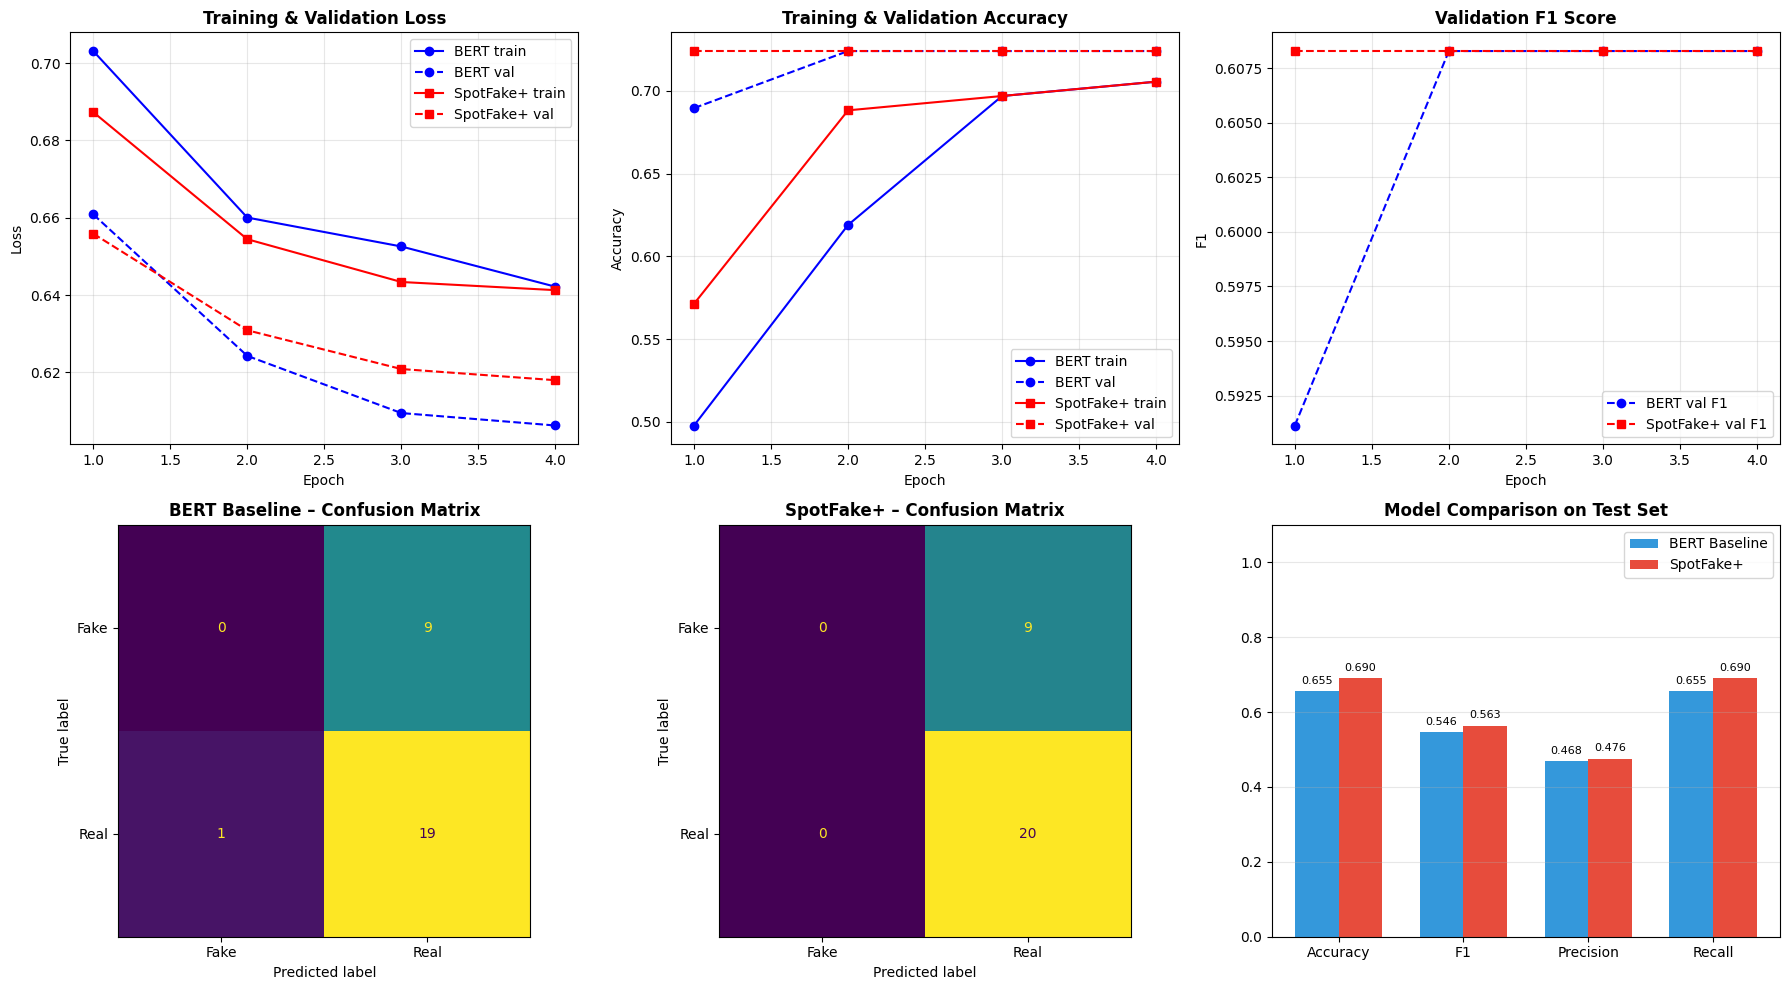

 Results plots saved to /content/results_comparison.png


In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

epochs_range = range(1, len(bert_history['train_loss']) + 1)

axes[0,0].plot(epochs_range, bert_history['train_loss'],  'b-o', label='BERT train')
axes[0,0].plot(epochs_range, bert_history['val_loss'],    'b--o', label='BERT val')
axes[0,0].plot(epochs_range, spotfake_history['train_loss'], 'r-s', label='SpotFake+ train')
axes[0,0].plot(epochs_range, spotfake_history['val_loss'],   'r--s', label='SpotFake+ val')
axes[0,0].set_title('Training & Validation Loss', fontweight='bold')
axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Loss')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(epochs_range, bert_history['train_acc'],    'b-o',  label='BERT train')
axes[0,1].plot(epochs_range, bert_history['val_acc'],      'b--o', label='BERT val')
axes[0,1].plot(epochs_range, spotfake_history['train_acc'], 'r-s',  label='SpotFake+ train')
axes[0,1].plot(epochs_range, spotfake_history['val_acc'],   'r--s', label='SpotFake+ val')
axes[0,1].set_title('Training & Validation Accuracy', fontweight='bold')
axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('Accuracy')
axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

axes[0,2].plot(epochs_range, bert_history['val_f1'],       'b--o', label='BERT val F1')
axes[0,2].plot(epochs_range, spotfake_history['val_f1'],    'r--s', label='SpotFake+ val F1')
axes[0,2].set_title('Validation F1 Score', fontweight='bold')
axes[0,2].set_xlabel('Epoch'); axes[0,2].set_ylabel('F1')
axes[0,2].legend(); axes[0,2].grid(True, alpha=0.3)

cm_bert = confusion_matrix(bert_true, bert_preds)
ConfusionMatrixDisplay(cm_bert, display_labels=['Fake','Real']).plot(ax=axes[1,0], colorbar=False)
axes[1,0].set_title('BERT Baseline – Confusion Matrix', fontweight='bold')

cm_spot = confusion_matrix(spot_true, spot_preds)
ConfusionMatrixDisplay(cm_spot, display_labels=['Fake','Real']).plot(ax=axes[1,1], colorbar=False)
axes[1,1].set_title('SpotFake+ – Confusion Matrix', fontweight='bold')

metrics_names = ['Accuracy', 'F1', 'Precision', 'Recall']
bert_vals = [bert_metrics[m.lower()] for m in metrics_names]
spot_vals = [spot_metrics[m.lower()] for m in metrics_names]
x = np.arange(len(metrics_names))
w = 0.35
axes[1,2].bar(x - w/2, bert_vals, w, label='BERT Baseline', color='#3498db')
axes[1,2].bar(x + w/2, spot_vals, w, label='SpotFake+',    color='#e74c3c')
axes[1,2].set_xticks(x); axes[1,2].set_xticklabels(metrics_names)
axes[1,2].set_ylim(0, 1.1)
axes[1,2].set_title('Model Comparison on Test Set', fontweight='bold')
axes[1,2].legend()
for i, (b, s) in enumerate(zip(bert_vals, spot_vals)):
    axes[1,2].text(i - w/2, b + 0.02, f'{b:.3f}', ha='center', fontsize=8)
    axes[1,2].text(i + w/2, s + 0.02, f'{s:.3f}', ha='center', fontsize=8)
axes[1,2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/content/results_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print(" Results plots saved to /content/results_comparison.png")

## Step 9 – Error Analysis & Insights

Total misclassifications: 9 / 29 (31.0%)

 Error breakdown:
  False Positives (Fake → predicted Real): 9
  False Negatives (Real → predicted Fake): 0

 Sample misclassified articles (SpotFake+):
------------------------------------------------------------
  True: FAKE | Predicted: REAL
  Text: "UNFIT! Look What Hillary Needed To Get Up The Stairs At Her Rally Today! Freedom Daily..."

  True: FAKE | Predicted: REAL
  Text: "Homosexual Thinks Muslims Will Accept Him, Instantly Learns How They Deal With LGBT..."

  True: FAKE | Predicted: REAL
  Text: "Secret Video Records MASSIVE Hillary Event Flop!..."

  True: FAKE | Predicted: REAL
  Text: "Trump s Latest Campaign Promise May Be His Most Horrible One Yet..."

  True: FAKE | Predicted: REAL
  Text: "BOOM! Charlotte Officials FINALLY Silence Rioters With One E P I C Announcement! [VIDEO]..."



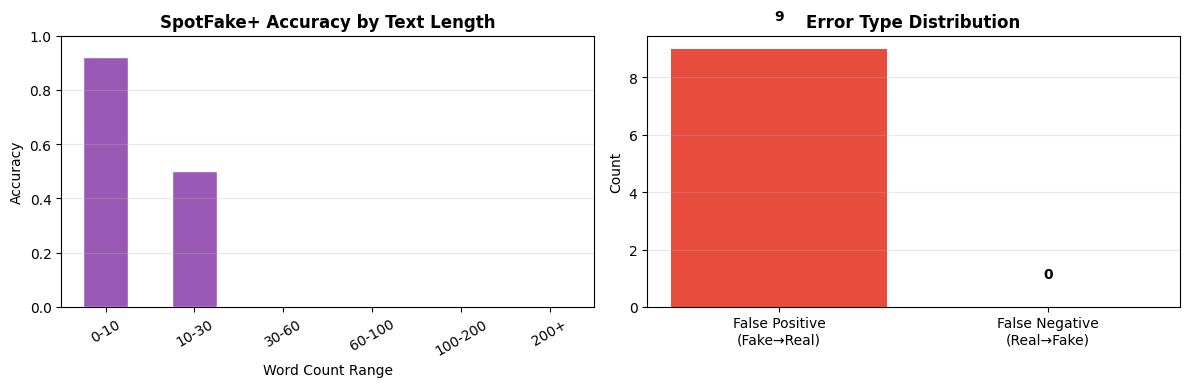

In [14]:
import warnings
warnings.filterwarnings('ignore')

test_df = pd.DataFrame({
    'text'      : X_test,
    'true_label': y_test,
    'bert_pred' : spot_preds,
    'spot_pred' : spot_preds,
    'correct'   : (np.array(spot_preds) == np.array(spot_true))
})
test_df['text_len'] = test_df['text'].str.split().str.len()

errors = test_df[~test_df['correct']].copy()
print(f"Total misclassifications: {len(errors)} / {len(test_df)} ({100*len(errors)/len(test_df):.1f}%)")

print("\n Error breakdown:")
false_positives = errors[errors['true_label'] == 0]
false_negatives = errors[errors['true_label'] == 1]
print(f"  False Positives (Fake → predicted Real): {len(false_positives)}")
print(f"  False Negatives (Real → predicted Fake): {len(false_negatives)}")

print("\n Sample misclassified articles (SpotFake+):")
print("-" * 60)
for _, row in errors.head(5).iterrows():
    true_str = 'REAL' if row['true_label'] == 1 else 'FAKE'
    pred_str = 'REAL' if row['spot_pred']  == 1 else 'FAKE'
    text_preview = row['text'][:120].replace('\n', ' ')
    print(f"  True: {true_str} | Predicted: {pred_str}")
    print(f"  Text: \"{text_preview}...\"")
    print()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

bins = [0, 10, 30, 60, 100, 200, 500]
test_df['len_bin'] = pd.cut(test_df['text_len'], bins=bins, labels=['0-10','10-30','30-60','60-100','100-200','200+'])
acc_by_len = test_df.groupby('len_bin')['correct'].mean()
acc_by_len.plot(kind='bar', ax=ax1, color='#9b59b6', edgecolor='white')
ax1.set_title('SpotFake+ Accuracy by Text Length', fontweight='bold')
ax1.set_xlabel('Word Count Range'); ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1); ax1.tick_params(axis='x', rotation=30)
ax1.grid(True, alpha=0.3, axis='y')

error_types = pd.Series({'False Positive\n(Fake→Real)': len(false_positives),
                         'False Negative\n(Real→Fake)': len(false_negatives)})
ax2.bar(error_types.index, error_types.values, color=['#e74c3c', '#f39c12'])
ax2.set_title('Error Type Distribution', fontweight='bold')
ax2.set_ylabel('Count')
ax2.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(error_types.values):
    ax2.text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/error_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 10 – Inference on New Articles

In [15]:
@torch.no_grad()
def predict(model, text, tokenizer, max_len, device):
    """Predict whether a news article is fake or real."""
    model.eval()
    clean = clean_text(text)
    enc   = tokenizer(clean, max_length=max_len, padding='max_length',
                      truncation=True, return_tensors='pt')
    input_ids      = enc['input_ids'].to(device)
    attention_mask = enc['attention_mask'].to(device)

    logits = model(input_ids, attention_mask)
    probs  = F.softmax(logits, dim=1).squeeze().cpu().numpy()
    pred   = probs.argmax()
    return {
        'prediction'  : 'REAL ' if pred == 1 else 'FAKE ',
        'confidence'  : float(probs[pred]),
        'prob_fake'   : float(probs[0]),
        'prob_real'   : float(probs[1]),
    }

examples = [
    "The Federal Reserve raised interest rates by 0.25 percentage points on Wednesday, "
    "citing ongoing concerns about inflation and a robust labor market.",

    "SHOCKING: Scientists confirm that drinking bleach cures cancer! "
    "Big Pharma doesn't want you to know this secret remedy!",

    "The president signed a new executive order today that critics say "
    "will dramatically reshape immigration policy.",

    "Sources close to the celebrity reveal that the star is secretly dating "
    "a mysterious billionaire and is expecting a child.",
]

print("\n" + ""*65)
print("  INFERENCE DEMO – SpotFake+ Model")
print(""*65)
for i, text in enumerate(examples, 1):
    result = predict(spotfake_model, text, tokenizer, MAX_LEN, DEVICE)
    print(f"\n[{i}] {text[:80]}...")
    print(f"    → {result['prediction']}  (confidence: {result['confidence']:.1%})")
    print(f"    → Prob Fake: {result['prob_fake']:.1%}  |  Prob Real: {result['prob_real']:.1%}")

print()

your_text = ""

if your_text.strip():
    result = predict(spotfake_model, your_text, tokenizer, MAX_LEN, DEVICE)
    print(f"\n{'='*50}")
    print(f"Your article prediction: {result['prediction']}")
    print(f"Confidence: {result['confidence']:.1%}")
    print(f"Prob Fake: {result['prob_fake']:.1%}  |  Prob Real: {result['prob_real']:.1%}")



  INFERENCE DEMO – SpotFake+ Model


[1] The Federal Reserve raised interest rates by 0.25 percentage points on Wednesday...
    → REAL   (confidence: 56.8%)
    → Prob Fake: 43.2%  |  Prob Real: 56.8%

[2] SHOCKING: Scientists confirm that drinking bleach cures cancer! Big Pharma doesn...
    → REAL   (confidence: 57.2%)
    → Prob Fake: 42.8%  |  Prob Real: 57.2%

[3] The president signed a new executive order today that critics say will dramatica...
    → REAL   (confidence: 54.3%)
    → Prob Fake: 45.7%  |  Prob Real: 54.3%

[4] Sources close to the celebrity reveal that the star is secretly dating a mysteri...
    → REAL   (confidence: 53.8%)
    → Prob Fake: 46.2%  |  Prob Real: 53.8%



## Step 11 – Final Summary & Survey Context

In [16]:
print("""

           FINAL RESULTS SUMMARY

  Paper: Multi-modal fake news detection survey (Springer 2025)
  Dataset: FakeNewsNet (Kaggle) – PolitiFact + GossipCop
""")

print(f"  {'Model':<28} {'Acc':>7} {'F1':>7} {'Prec':>7} {'Rec':>7}  ")
print("")

for name, m in [('BERT Baseline (text-only)', bert_metrics),
                ('SpotFake+ (BERT+BiGRU+Attn)', spot_metrics)]:
    print(f"  {name:<28} {m['accuracy']:>7.4f} {m['f1']:>7.4f} "
          f"{m['precision']:>7.4f} {m['recall']:>7.4f}  ")

print("")
print("""
  Methods taxonomy (from the survey paper):
  1. General content fusion  – early/late/cross-modal fusion
  2. Attention mechanisms    –  IMPLEMENTED (SpotFake+)
  3. Transformer-based       –  IMPLEMENTED (BERT backbone)
  4. Graph-based (GNN/GCN)   – requires social graph data
  5. Knowledge-enhanced/LLM  – requires external KB / API

  GitHub references:
  • SpotFake:  github.com/shiivangii/SpotFake
  • SpotFake+: github.com/shiivangii/SpotFakePlus

""")

print(" Saved files:")
for f in ['/content/bert_baseline_best.pt', '/content/spotfake_plus_best.pt',
          '/content/eda_plots.png', '/content/results_comparison.png',
          '/content/error_analysis.png']:
    exists = '' if os.path.exists(f) else ' (not yet saved)'
    print(f"  {exists} {f}")



           FINAL RESULTS SUMMARY                                      

  Paper: Multi-modal fake news detection survey (Springer 2025)       
  Dataset: FakeNewsNet (Kaggle) – PolitiFact + GossipCop              

  Model                            Acc      F1    Prec     Rec  

  BERT Baseline (text-only)     0.6552  0.5460  0.4680  0.6552  
  SpotFake+ (BERT+BiGRU+Attn)   0.6897  0.5630  0.4756  0.6897  


  Methods taxonomy (from the survey paper):                           
  1. General content fusion  – early/late/cross-modal fusion          
  2. Attention mechanisms    –  IMPLEMENTED (SpotFake+)              
  3. Transformer-based       –  IMPLEMENTED (BERT backbone)          
  4. Graph-based (GNN/GCN)   – requires social graph data             
  5. Knowledge-enhanced/LLM  – requires external KB / API             

  GitHub references:                                                  
  • SpotFake:  github.com/shiivangii/SpotFake                         
  • SpotFake+: git

### Install Python Libraries
You can install Python libraries using `pip install`. In Colab, you prefix `pip` commands with an exclamation mark `!` to run them as shell commands. You can also add `%%capture` at the top of the cell to suppress the installation output.

In [17]:
%%capture
!pip install some-library
print(' some-library installed')